In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import pytz

def analyze_bias_vs_meteo(sensor_file, gapa_file, start_date, end_date, sensor_id):
    """
    Analyze how PM10 bias varies with RH and temperature.
    This will tell us if RH/temp can actually explain the sensor error.
    """
    
    # Load sensor data
    sensor = pd.read_csv(sensor_file, parse_dates=['timestamp'])
    sensor = sensor[['timestamp_local','rh','temp','pm10']].dropna(subset=['pm10'])
    sensor.rename(columns={'timestamp_local':'time'}, inplace=True)
    
    sensor['time'] = pd.to_datetime(sensor['time'])
    est = pytz.timezone('US/Eastern')
    sensor['time'] = sensor['time'].dt.tz_convert(est)
    sensor['time'] = sensor['time'].dt.tz_localize(None)
    sensor['dayhour'] = sensor['time'].dt.strftime('%Y-%m-%d %H')
    
    sensor = sensor[(sensor['time'] >= start_date) & (sensor['time'] <= end_date)]
    sensor = sensor[::-1].reset_index(drop=True)
    
    # Remove outliers
    Q1 = sensor['pm10'].quantile(0.25)
    Q3 = sensor['pm10'].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 3 * IQR
    reasonable_max = 150
    outliers = (sensor['pm10'] > upper_bound) | (sensor['pm10'] > reasonable_max)
    sensor = sensor[~outliers].copy()
    
    # Split for training
    split_idx = int(len(sensor) * 0.75)
    sensor_train = sensor.iloc[:split_idx]
    
    print(f"Sensor {sensor_id} Training Data:")
    print(f"  PM10: mean={sensor_train['pm10'].mean():.1f}, std={sensor_train['pm10'].std():.1f}")
    print(f"  RH: mean={sensor_train['rh'].mean():.1f}, std={sensor_train['rh'].std():.1f}")
    print(f"  Temp: mean={sensor_train['temp'].mean():.1f}, std={sensor_train['temp'].std():.1f}")
    
    # Load GAPA data
    gapa = pd.read_csv(gapa_file, header=2)
    gapa.columns = ['Date', 'PMHR_2', 'PMHR', 'PMHR10', '24H_PMHR10', 'PMHRC', '24H_PMHR']
    gapa = gapa[['Date', 'PMHR10']]
    gapa['time'] = pd.to_datetime(gapa['Date'], format='%d-%b-%Y %H:%M')
    gapa['dayhour'] = gapa['time'].dt.strftime('%Y-%m-%d %H')
    gapa.rename(columns={'PMHR10':'rpm10'}, inplace=True)
    gapa = gapa.sort_values('time').reset_index(drop=True)
    
    # Split GAPA for training
    split_idx_gapa = int(len(gapa) * 0.75)
    gapa_train = gapa.iloc[:split_idx_gapa]
    
    # Aggregate by hour
    sensor_hourly = sensor_train.groupby('dayhour').agg(
        sensor_pm10=('pm10', 'mean'),
        sensor_rh=('rh', 'mean'),
        sensor_temp=('temp', 'mean')
    ).reset_index()
    
    gapa_hourly = gapa_train.groupby('dayhour').agg(
        gapa_pm10=('rpm10', 'mean')
    ).reset_index()
    
    # Merge
    merged = pd.merge(sensor_hourly, gapa_hourly, on='dayhour').dropna()
    
    if len(merged) < 10:
        print("ERROR: Not enough matched data!")
        return None
    
    # Calculate bias and error metrics
    merged['bias'] = merged['sensor_pm10'] - merged['gapa_pm10']  # Sensor - Reference
    merged['abs_error'] = np.abs(merged['bias'])
    merged['rel_error'] = merged['bias'] / merged['gapa_pm10'] * 100  # Percent error
    
    print(f"\nMatched hours: {len(merged)}")
    print(f"\nBias Statistics:")
    print(f"  Mean bias: {merged['bias'].mean():.2f} µg/m³")
    print(f"  Std bias: {merged['bias'].std():.2f} µg/m³")
    print(f"  MAE: {merged['abs_error'].mean():.2f} µg/m³")
    print(f"  Mean relative error: {merged['rel_error'].mean():.1f}%")
    
    # Correlations between bias and meteorological variables
    print(f"\nCorrelations with Bias:")
    corr_rh_bias, p_rh = pearsonr(merged['sensor_rh'], merged['bias'])
    corr_temp_bias, p_temp = pearsonr(merged['sensor_temp'], merged['bias'])
    corr_pm_bias, p_pm = pearsonr(merged['sensor_pm10'], merged['bias'])
    
    print(f"  RH vs Bias: r={corr_rh_bias:.3f} (p={p_rh:.3e})")
    print(f"  Temp vs Bias: r={corr_temp_bias:.3f} (p={p_temp:.3e})")
    print(f"  Sensor PM10 vs Bias: r={corr_pm_bias:.3f} (p={p_pm:.3e})")
    
    # Check if bias varies significantly with RH/temp
    print(f"\nCorrelations with Absolute Error:")
    corr_rh_abs, _ = pearsonr(merged['sensor_rh'], merged['abs_error'])
    corr_temp_abs, _ = pearsonr(merged['sensor_temp'], merged['abs_error'])
    print(f"  RH vs |Error|: r={corr_rh_abs:.3f}")
    print(f"  Temp vs |Error|: r={corr_temp_abs:.3f}")
    
    # Create comprehensive visualization
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # Row 1: Sensor vs GAPA
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(merged['sensor_pm10'], merged['gapa_pm10'], alpha=0.5, s=30)
    ax1.plot([0, max(merged['sensor_pm10'].max(), merged['gapa_pm10'].max())],
             [0, max(merged['sensor_pm10'].max(), merged['gapa_pm10'].max())],
             'r--', linewidth=2)
    r_overall = merged[['sensor_pm10', 'gapa_pm10']].corr().iloc[0,1]
    ax1.set_xlabel('Sensor PM10 (µg/m³)')
    ax1.set_ylabel('GAPA PM10 (µg/m³)')
    ax1.set_title(f'Overall: R={r_overall:.3f}')
    ax1.grid(True, alpha=0.3)
    
    # Bias vs sensor PM10
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.scatter(merged['sensor_pm10'], merged['bias'], alpha=0.5, s=30, c=merged['sensor_rh'], cmap='viridis')
    ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax2.set_xlabel('Sensor PM10 (µg/m³)')
    ax2.set_ylabel('Bias (Sensor - GAPA)')
    ax2.set_title(f'Bias vs PM10: R={corr_pm_bias:.3f}')
    ax2.grid(True, alpha=0.3)
    cbar = plt.colorbar(ax2.collections[0], ax=ax2)
    cbar.set_label('RH (%)')
    
    # Bias vs GAPA PM10
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.scatter(merged['gapa_pm10'], merged['bias'], alpha=0.5, s=30, c=merged['sensor_temp'], cmap='coolwarm')
    ax3.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax3.set_xlabel('GAPA PM10 (µg/m³)')
    ax3.set_ylabel('Bias (Sensor - GAPA)')
    ax3.set_title('Bias vs True PM10')
    ax3.grid(True, alpha=0.3)
    cbar = plt.colorbar(ax3.collections[0], ax=ax3)
    cbar.set_label('Temp (°C)')
    
    # Row 2: RH effects
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.scatter(merged['sensor_rh'], merged['bias'], alpha=0.5, s=30)
    ax4.axhline(y=0, color='r', linestyle='--', linewidth=2)
    z = np.polyfit(merged['sensor_rh'], merged['bias'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(merged['sensor_rh'].min(), merged['sensor_rh'].max(), 100)
    ax4.plot(x_line, p(x_line), 'b-', linewidth=2, alpha=0.7)
    ax4.set_xlabel('Relative Humidity (%)')
    ax4.set_ylabel('Bias (Sensor - GAPA)')
    ax4.set_title(f'RH vs Bias: R={corr_rh_bias:.3f}')
    ax4.grid(True, alpha=0.3)
    
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.scatter(merged['sensor_rh'], merged['abs_error'], alpha=0.5, s=30)
    z = np.polyfit(merged['sensor_rh'], merged['abs_error'], 1)
    p = np.poly1d(z)
    ax5.plot(x_line, p(x_line), 'b-', linewidth=2, alpha=0.7)
    ax5.set_xlabel('Relative Humidity (%)')
    ax5.set_ylabel('Absolute Error')
    ax5.set_title(f'RH vs |Error|: R={corr_rh_abs:.3f}')
    ax5.grid(True, alpha=0.3)
    
    # RH bins
    ax6 = fig.add_subplot(gs[1, 2])
    merged['rh_bin'] = pd.cut(merged['sensor_rh'], bins=5)
    rh_groups = merged.groupby('rh_bin', observed=True)['bias'].agg(['mean', 'std', 'count'])
    rh_groups['mean'].plot(kind='bar', ax=ax6, yerr=rh_groups['std'], capsize=4)
    ax6.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax6.set_xlabel('RH Bins')
    ax6.set_ylabel('Mean Bias')
    ax6.set_title('Bias by RH Range')
    ax6.tick_params(axis='x', rotation=45)
    ax6.grid(True, alpha=0.3, axis='y')
    
    # Row 3: Temperature effects
    ax7 = fig.add_subplot(gs[2, 0])
    ax7.scatter(merged['sensor_temp'], merged['bias'], alpha=0.5, s=30)
    ax7.axhline(y=0, color='r', linestyle='--', linewidth=2)
    z = np.polyfit(merged['sensor_temp'], merged['bias'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(merged['sensor_temp'].min(), merged['sensor_temp'].max(), 100)
    ax7.plot(x_line, p(x_line), 'b-', linewidth=2, alpha=0.7)
    ax7.set_xlabel('Temperature (°C)')
    ax7.set_ylabel('Bias (Sensor - GAPA)')
    ax7.set_title(f'Temp vs Bias: R={corr_temp_bias:.3f}')
    ax7.grid(True, alpha=0.3)
    
    ax8 = fig.add_subplot(gs[2, 1])
    ax8.scatter(merged['sensor_temp'], merged['abs_error'], alpha=0.5, s=30)
    z = np.polyfit(merged['sensor_temp'], merged['abs_error'], 1)
    p = np.poly1d(z)
    ax8.plot(x_line, p(x_line), 'b-', linewidth=2, alpha=0.7)
    ax8.set_xlabel('Temperature (°C)')
    ax8.set_ylabel('Absolute Error')
    ax8.set_title(f'Temp vs |Error|: R={corr_temp_abs:.3f}')
    ax8.grid(True, alpha=0.3)
    
    # Temp bins
    ax9 = fig.add_subplot(gs[2, 2])
    merged['temp_bin'] = pd.cut(merged['sensor_temp'], bins=5)
    temp_groups = merged.groupby('temp_bin', observed=True)['bias'].agg(['mean', 'std', 'count'])
    temp_groups['mean'].plot(kind='bar', ax=ax9, yerr=temp_groups['std'], capsize=4)
    ax9.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax9.set_xlabel('Temp Bins')
    ax9.set_ylabel('Mean Bias')
    ax9.set_title('Bias by Temperature Range')
    ax9.tick_params(axis='x', rotation=45)
    ax9.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(f'Sensor {sensor_id}: Bias Analysis vs Meteorological Conditions', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    plt.savefig(f'bias_analysis_{sensor_id}.png', dpi=200, bbox_inches='tight')
    print(f"\nVisualization saved as: bias_analysis_{sensor_id}.png")
    plt.show()
    
    return merged

# Example usage:
"""
merged = analyze_bias_vs_meteo(
    '../ShortenedData/MOD-00589-RAW.csv',
    'PM10&PM2.5.csv',
    '2025-05-31',
    '2025-07-14',
    'MOD-00589'
)
"""

"\nmerged = analyze_bias_vs_meteo(\n    '../ShortenedData/MOD-00589-RAW.csv',\n    'PM10&PM2.5.csv',\n    '2025-05-31',\n    '2025-07-14',\n    'MOD-00589'\n)\n"

Sensor MOD-00589 Training Data:
  PM10: mean=22.5, std=13.1
  RH: mean=73.3, std=20.3
  Temp: mean=27.1, std=6.5

Matched hours: 700

Bias Statistics:
  Mean bias: 2.68 µg/m³
  Std bias: 11.55 µg/m³
  MAE: 8.16 µg/m³
  Mean relative error: 18.4%

Correlations with Bias:
  RH vs Bias: r=0.343 (p=8.722e-21)
  Temp vs Bias: r=-0.307 (p=8.822e-17)
  Sensor PM10 vs Bias: r=0.774 (p=1.045e-140)

Correlations with Absolute Error:
  RH vs |Error|: r=0.432
  Temp vs |Error|: r=-0.426

Visualization saved as: bias_analysis_MOD-00589.png


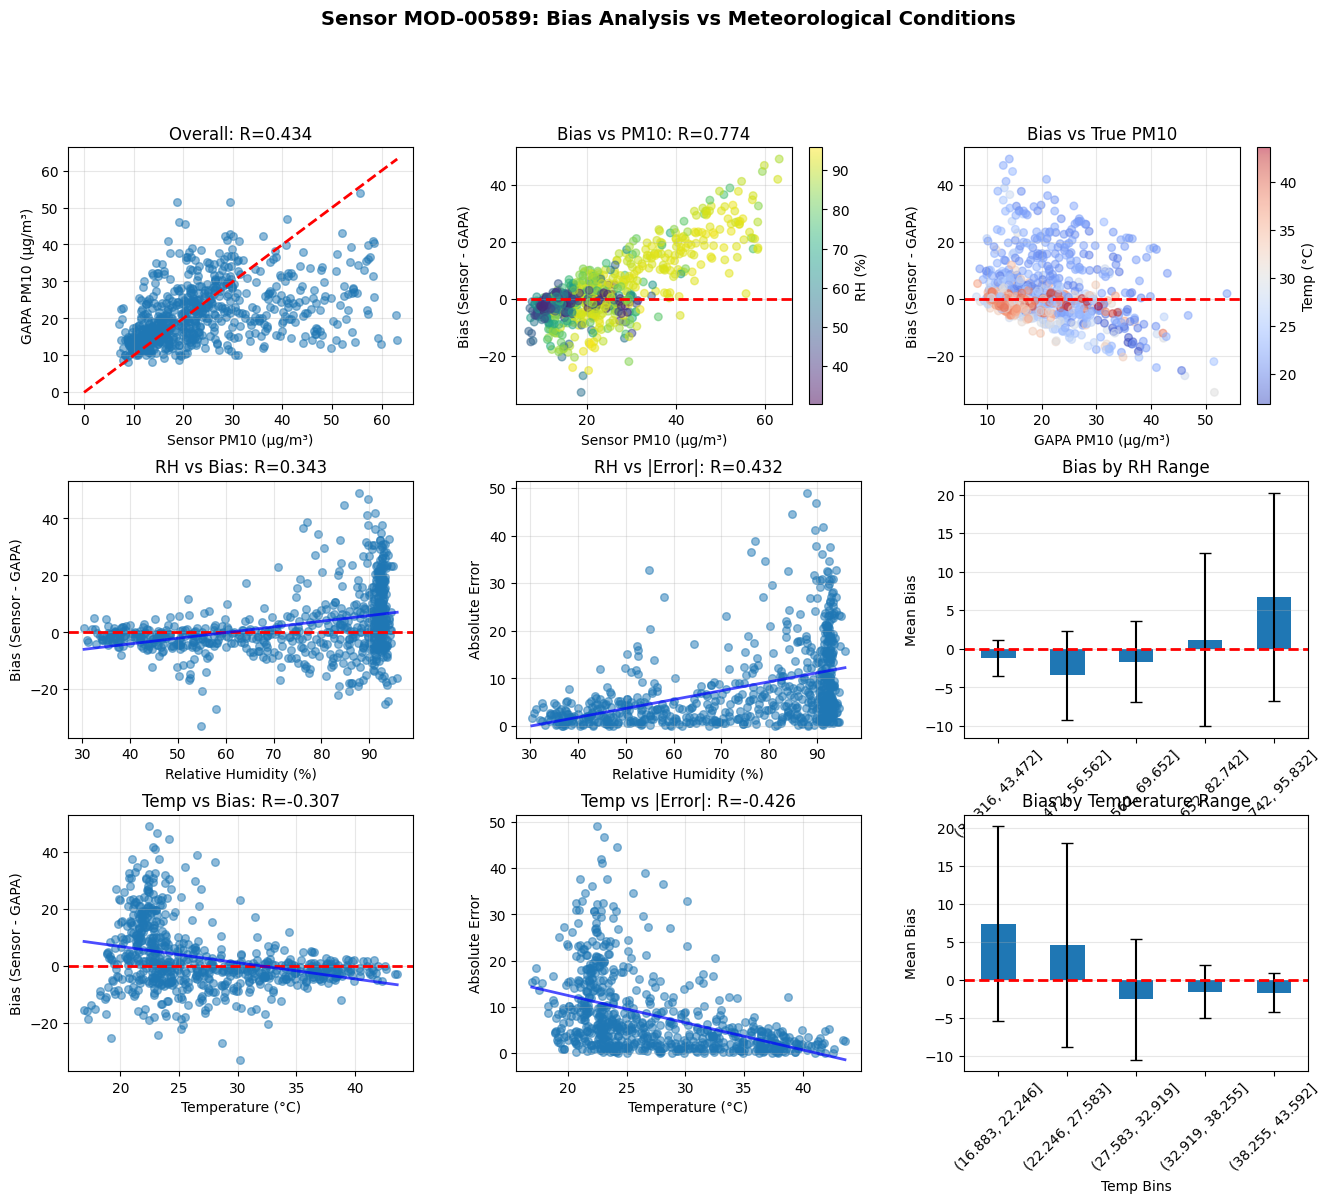

In [21]:
merged = analyze_bias_vs_meteo(
    '../ShortenedData/MOD-00589-RAW.csv',
    'PM10&PM2.5.csv',
    '2025-05-31',
    '2025-07-14',
    'MOD-00589'
)